# Certified Counterfactual Generation

This notebook demonstrates the **CertifiedAtlas** API for generating certified counterfactual explanations.

The method works in two phases:
1. **Offline (build)**: Compute LiRPA bounds for all training samples, constructing certified polytopes
2. **Online (query)**: For a query point, project onto the nearest certified polytopes using QP

Key guarantees:
- **Validity**: Counterfactuals lie within certified regions → model prediction is guaranteed
- **Proximity**: QP projection finds the closest valid point
- **Efficiency**: BVH spatial indexing enables O(log N) search

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from preimage_sampling.models import SimpleClassifier
from preimage_sampling.atlas import CertifiedAtlas

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Load Data & Model

In [2]:
# Load dataset
dataset = torch.load('data/datasets/test_spiral.pt', weights_only=True)
n_classes = len(set(y.item() for _, y in dataset))
print(f'Dataset: {len(dataset)} samples, {n_classes} classes')

# Load model
model = SimpleClassifier(num_classes=n_classes).to(device)
model.load_state_dict(torch.load('data/models/simple_classifier.pth', 
                                  map_location=device, weights_only=True))
model.eval()
print('Model loaded.')

Dataset: 400 samples, 5 classes
Model loaded.


## 3 – Build Certified Atlas

This is the **offline phase**. We compute LiRPA bounds for all samples and build BVH indices.

Parameters:
- `eps`: Perturbation radius (larger → bigger polytopes but looser bounds)
- `norm`: Lp norm (1, 2, or np.inf)

In [15]:
# Create and build the atlas
atlas = CertifiedAtlas(model, dataset, device)

atlas.build(
    eps=0.1,           # Perturbation radius
    norm=2,             # L2 norm
    build_unions=True,  # Build polygon unions for visualization (2D only)
    verbose=True
)

Building certified atlas (eps=0.1, L2 norm)...
  Computing LiRPA bounds...


Computing bounds: 100%|██████████| 5/5 [00:00<00:00, 37.28it/s]

  Building BVH spatial indices...
    Class 0: 80 polytopes, tree depth 8
    Class 1: 80 polytopes, tree depth 8
    Class 2: 80 polytopes, tree depth 8
    Class 3: 80 polytopes, tree depth 8
    Class 4: 80 polytopes, tree depth 8
  Building polygon unions...
Done! Total: 400 polytopes across 5 classes


CertifiedAtlas(n_classes=5, built)

In [16]:
# Print summary
print(atlas.summary())

CertifiedAtlas Summary
Classes: 5
Perturbation: eps=0.1, L2 norm
Device: cuda

  Class 0:   80 polytopes (BVH depth 8)
  Class 1:   80 polytopes (BVH depth 8)
  Class 2:   80 polytopes (BVH depth 8)
  Class 3:   80 polytopes (BVH depth 8)
  Class 4:   80 polytopes (BVH depth 8)

Total polytopes: 400


In [17]:
from preimage_sampling.geometry.polytopes import make_polygon

print("Polytope validity analysis:\n")

for label in range(atlas.n_classes):
    bd = atlas.bounds[label]
    n_total = len(bd['X'])
    
    n_valid = 0
    n_zero_area = 0
    n_failed = 0
    areas = []
    
    for i in range(n_total):
        poly = make_polygon(bd['lA'][i], bd['lbias'][i], bd['X'][i], atlas.eps)
        if poly is None:
            n_failed += 1
        elif poly.area < 1e-10:
            n_zero_area += 1
        else:
            n_valid += 1
            areas.append(poly.area)
    
    print(f"Class {label}: {n_total} polytopes")
    print(f"  Valid (area > 0):     {n_valid:3d} ({100*n_valid/n_total:.1f}%)")
    print(f"  Near-zero area:       {n_zero_area:3d}")
    print(f"  Failed to construct:  {n_failed:3d}")
    if areas:
        print(f"  Area range: [{min(areas):.6f}, {max(areas):.6f}]")
    print()

Polytope validity analysis:

Class 0: 80 polytopes
  Valid (area > 0):      51 (63.8%)
  Near-zero area:         0
  Failed to construct:   29
  Area range: [0.007272, 0.040000]

Class 1: 80 polytopes
  Valid (area > 0):      57 (71.2%)
  Near-zero area:         0
  Failed to construct:   23
  Area range: [0.008915, 0.040000]

Class 2: 80 polytopes
  Valid (area > 0):      59 (73.8%)
  Near-zero area:         0
  Failed to construct:   21
  Area range: [0.011925, 0.040000]

Class 3: 80 polytopes
  Valid (area > 0):      39 (48.8%)
  Near-zero area:         0
  Failed to construct:   41
  Area range: [0.020820, 0.040000]

Class 4: 80 polytopes
  Valid (area > 0):      72 (90.0%)
  Near-zero area:         0
  Failed to construct:    8
  Area range: [0.009691, 0.039983]



## 4 – Visualize Certified Regions (2D only)

/tmp/ipykernel_66820/814426251.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', atlas.n_classes)


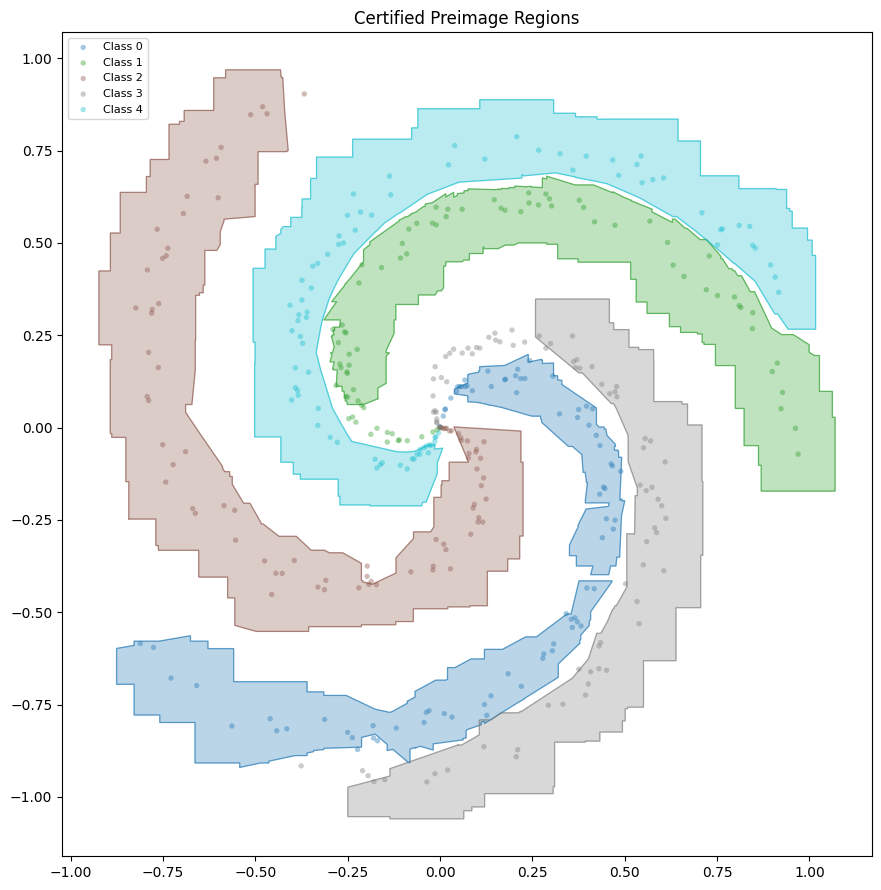

In [18]:
def plot_atlas(atlas, ax=None, alpha=0.3):
    """Plot certified regions for all classes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    cmap = plt.cm.get_cmap('tab10', atlas.n_classes)
    
    for label in range(atlas.n_classes):
        color = cmap(label)
        
        # Plot data points
        X = atlas.bounds[label]['X']
        ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.4, 
                   color=color, edgecolors='none', label=f'Class {label}')
        
        # Plot certified region
        union = atlas.get_class_union(label)
        if union.is_empty:
            continue
            
        geoms = [union] if union.geom_type == 'Polygon' else list(union.geoms)
        for g in geoms:
            if g.is_empty or g.area < 1e-12:
                continue
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, alpha=alpha, color=color)
            ax.plot(xs, ys, lw=0.8, color=color, alpha=0.6)
    
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=8)
    return ax

fig, ax = plt.subplots(figsize=(9, 9))
plot_atlas(atlas, ax)
ax.set_title('Certified Preimage Regions')
plt.tight_layout()
plt.show()

## 5 – Generate Counterfactuals

This is the **online phase**. For each query point, we find the closest point in the target class's certified region.

In [19]:
# Select query points from class 0
source_class = 0
query_points = atlas.bounds[source_class]['X'][:5]

print(f'Generating counterfactuals for {len(query_points)} queries from class {source_class}\n')

# Generate counterfactuals for each target class
all_results = {}

for target_class in range(atlas.n_classes):
    if target_class == source_class:
        continue
    
    print(f'Target class {target_class}:')
    results = []
    
    for i, x0 in enumerate(query_points):
        result = atlas.find_counterfactual(x0, target_class, method='bvh')
        results.append(result)
        
        status = '✓' if result.success else '✗'
        print(f'  Query {i}: dist={result.distance:.4f}, QPs={result.n_qp_solved} {status}')
    
    all_results[target_class] = results
    print()

Generating counterfactuals for 5 queries from class 0

Target class 1:
  Query 0: dist=0.7228, QPs=16 ✓
  Query 1: dist=0.8011, QPs=18 ✓
  Query 2: dist=0.7595, QPs=16 ✓
  Query 3: dist=0.1023, QPs=12 ✓
  Query 4: dist=0.8054, QPs=17 ✓

Target class 2:
  Query 0: dist=0.2610, QPs=3 ✓
  Query 1: dist=0.2913, QPs=1 ✓
  Query 2: dist=0.2949, QPs=4 ✓
  Query 3: dist=0.0412, QPs=17 ✓
  Query 4: dist=0.3087, QPs=2 ✓

Target class 3:
  Query 0: dist=0.0628, QPs=3 ✓
  Query 1: dist=0.0877, QPs=5 ✓
  Query 2: dist=0.0877, QPs=8 ✓
  Query 3: dist=0.1131, QPs=20 ✓
  Query 4: dist=0.0957, QPs=6 ✓

Target class 4:
  Query 0: dist=0.5548, QPs=4 ✓
  Query 1: dist=0.6200, QPs=2 ✓
  Query 2: dist=0.5879, QPs=1 ✓
  Query 3: dist=0.0803, QPs=18 ✓
  Query 4: dist=0.6311, QPs=2 ✓



## 6 – Verify Counterfactuals

Since counterfactuals lie within certified polytopes, they are **guaranteed** to be classified correctly.

In [20]:
print('Verifying counterfactual validity:\n')

all_valid = True
for target_class, results in all_results.items():
    print(f'Target class {target_class}:')
    for i, result in enumerate(results):
        if not result.success:
            print(f'  Query {i}: FAILED (no projection found)')
            all_valid = False
            continue
        
        verification = atlas.verify_counterfactual(result.x_cf, target_class)
        status = '✓' if verification['valid'] else '✗'
        print(f'  Query {i}: pred={verification["predicted"]}, target={target_class} {status}')
        # Print logits
        # print(f'           logits={verification["logits"].round(2)}')
        
        if not verification['valid']:
            all_valid = False
    print()

print('=' * 40)
print(f'All counterfactuals valid: {all_valid}')

Verifying counterfactual validity:

Target class 1:
  Query 0: pred=1, target=1 ✓
  Query 1: pred=1, target=1 ✓
  Query 2: pred=1, target=1 ✓
  Query 3: pred=1, target=1 ✓
  Query 4: pred=1, target=1 ✓

Target class 2:
  Query 0: pred=2, target=2 ✓
  Query 1: pred=2, target=2 ✓
  Query 2: pred=2, target=2 ✓
  Query 3: pred=2, target=2 ✓
  Query 4: pred=2, target=2 ✓

Target class 3:
  Query 0: pred=3, target=3 ✓
  Query 1: pred=3, target=3 ✓
  Query 2: pred=3, target=3 ✓
  Query 3: pred=3, target=3 ✓
  Query 4: pred=3, target=3 ✓

Target class 4:
  Query 0: pred=4, target=4 ✓
  Query 1: pred=4, target=4 ✓
  Query 2: pred=4, target=4 ✓
  Query 3: pred=4, target=4 ✓
  Query 4: pred=4, target=4 ✓

All counterfactuals valid: True


In [21]:
# Check if counterfactuals satisfy the polytope constraints
print("Analyzing counterfactual constraint satisfaction:\n")

for target_class, results in all_results.items():
    print(f"Target class {target_class}:")
    bd = atlas.bounds[target_class]
    
    for i, result in enumerate(results):
        if not result.success:
            continue
        
        x_cf = result.x_cf
        idx = result.anchor_idx
        
        # Get the polytope constraints
        A = bd['lA'][idx]
        b = bd['lbias'][idx]
        center = bd['X'][idx]
        
        # Check LiRPA constraints: A @ x + b >= 0
        margins = A @ x_cf + b
        min_margin = margins.min()
        
        # Check box constraints: |x - center|_inf <= eps
        box_violation = np.abs(x_cf - center).max() - atlas.eps
        
        # Check if polytope is valid for visualization
        poly = make_polygon(A, b, center, atlas.eps)
        poly_valid = poly is not None and poly.area > 1e-10
        
        # Verify with model
        verification = atlas.verify_counterfactual(x_cf, target_class)
        
        constraint_ok = min_margin >= -1e-6 and box_violation <= 1e-6
        
        print(f"  Query {i}: min_margin={min_margin:+.6f}, box_viol={box_violation:+.6f}")
        print(f"           polytope_visible={poly_valid}, model_pred={verification['predicted']}, "
              f"{'✓ VALID' if verification['valid'] else '✗ FAILED'}")
    print()

Analyzing counterfactual constraint satisfaction:

Target class 1:
  Query 0: min_margin=-0.000000, box_viol=-0.002462
           polytope_visible=False, model_pred=1, ✓ VALID
  Query 1: min_margin=-0.000000, box_viol=-0.002462
           polytope_visible=False, model_pred=1, ✓ VALID
  Query 2: min_margin=-0.000000, box_viol=-0.002462
           polytope_visible=False, model_pred=1, ✓ VALID
  Query 3: min_margin=+2.058533, box_viol=-0.003041
           polytope_visible=False, model_pred=1, ✓ VALID
  Query 4: min_margin=-0.000000, box_viol=-0.002462
           polytope_visible=False, model_pred=1, ✓ VALID

Target class 2:
  Query 0: min_margin=+3.920085, box_viol=-0.004733
           polytope_visible=True, model_pred=2, ✓ VALID
  Query 1: min_margin=+6.968034, box_viol=-0.001293
           polytope_visible=True, model_pred=2, ✓ VALID
  Query 2: min_margin=+5.725056, box_viol=-0.005503
           polytope_visible=True, model_pred=2, ✓ VALID
  Query 3: min_margin=-0.000000, box_viol=-0.01

### Diagnostic: Why did some counterfactuals fail?

Let's check if counterfactuals satisfy the LiRPA constraints and whether their polytopes are visible.

## 7 – Visualize Counterfactual Trajectories (Interactive)

Using Plotly for interactive zooming and panning.

In [22]:
from plotly.colors import qualitative
import plotly.graph_objects as go

# Color palette
colors = qualitative.Plotly[:atlas.n_classes]

fig = go.Figure()

# Plot certified regions as filled polygons
for label in range(atlas.n_classes):
    union = atlas.get_class_union(label)
    if union.is_empty:
        continue
    
    geoms = [union] if union.geom_type == 'Polygon' else list(union.geoms)
    for idx, g in enumerate(geoms):
        if g.is_empty or g.area < 1e-12:
            continue
        xs, ys = g.exterior.xy
        fig.add_trace(go.Scatter(
            x=list(xs), y=list(ys),
            fill='toself',
            fillcolor=colors[label],
            opacity=0.2,
            line=dict(color=colors[label], width=1),
            name=f'Class {label} region' if idx == 0 else None,
            showlegend=(idx == 0),
            legendgroup=f'class_{label}',
            hoverinfo='skip'
        ))

# Plot data points for each class
for label in range(atlas.n_classes):
    X = atlas.bounds[label]['X']
    fig.add_trace(go.Scatter(
        x=X[:, 0], y=X[:, 1],
        mode='markers',
        marker=dict(size=6, color=colors[label], opacity=0.5),
        name=f'Class {label} data',
        legendgroup=f'class_{label}',
        hovertemplate=f'Class {label}<br>x: %{{x:.3f}}<br>y: %{{y:.3f}}<extra></extra>'
    ))

# Plot query points
fig.add_trace(go.Scatter(
    x=query_points[:, 0], y=query_points[:, 1],
    mode='markers',
    marker=dict(size=15, color='black', symbol='star'),
    name='Query points',
    hovertemplate='Query<br>x: %{x:.3f}<br>y: %{y:.3f}<extra></extra>'
))

# Plot counterfactual arrows and points
for target_class, results in all_results.items():
    color = colors[target_class]
    
    for i, result in enumerate(results):
        if not result.success:
            continue
        
        x0 = query_points[i]
        x_cf = result.x_cf
        
        # Arrow line from query to counterfactual
        fig.add_trace(go.Scatter(
            x=[x0[0], x_cf[0]], y=[x0[1], x_cf[1]],
            mode='lines',
            line=dict(color=color, width=2),
            showlegend=False,
            hoverinfo='skip'
        ))
        
        # Counterfactual point
        fig.add_trace(go.Scatter(
            x=[x_cf[0]], y=[x_cf[1]],
            mode='markers',
            marker=dict(size=12, color=color, line=dict(color='black', width=1)),
            name=f'CF → Class {target_class}' if i == 0 else None,
            showlegend=(i == 0),
            legendgroup=f'cf_{target_class}',
            hovertemplate=(
                f'Counterfactual → Class {target_class}<br>'
                f'x: %{{x:.3f}}<br>y: %{{y:.3f}}<br>'
                f'Distance: {result.distance:.4f}<extra></extra>'
            )
        ))

fig.update_layout(
    title=f'Counterfactuals: Class {source_class} → Other Classes (zoom with scroll, pan with drag)',
    xaxis=dict(title='x₁', scaleanchor='y', scaleratio=1),
    yaxis=dict(title='x₂'),
    width=850,
    height=850,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
    hovermode='closest'
)

fig.show()

## 8 – Benchmark: BVH vs k-NN Search

In [23]:
import time

# Test on more queries
n_test = 20
test_queries = atlas.bounds[0]['X'][:n_test]
target = 2

print(f'Benchmarking {n_test} queries → class {target}')
print(f'Total polytopes in target: {atlas.bvh_indices[target].n_polytopes}')
print('=' * 50)

bvh_qps = []
knn_qps = []

for i, x0 in enumerate(test_queries):
    # BVH search
    result_bvh = atlas.find_counterfactual(x0, target, method='bvh')
    
    # k-NN search (k = all polytopes for fair comparison)
    result_knn = atlas.find_counterfactual(x0, target, method='knn', 
                                            k=atlas.bvh_indices[target].n_polytopes)
    
    bvh_qps.append(result_bvh.n_qp_solved)
    knn_qps.append(result_knn.n_qp_solved)
    
    # Verify same result
    match = np.allclose(result_bvh.distance, result_knn.distance, atol=1e-5)
    status = '✓' if match else '✗'
    
    print(f'Query {i:2d}: BVH {result_bvh.n_qp_solved:3d} QPs | '
          f'k-NN {result_knn.n_qp_solved:3d} QPs | dist={result_bvh.distance:.4f} {status}')

print('=' * 50)
print(f'Average QPs:  BVH = {np.mean(bvh_qps):.1f},  k-NN = {np.mean(knn_qps):.1f}')
print(f'Speedup:      {np.mean(knn_qps) / np.mean(bvh_qps):.2f}x fewer QPs with BVH')

Benchmarking 20 queries → class 2
Total polytopes in target: 80
Query  0: BVH   3 QPs | k-NN  80 QPs | dist=0.2610 ✓
Query  1: BVH   1 QPs | k-NN  80 QPs | dist=0.2913 ✓
Query  2: BVH   4 QPs | k-NN  80 QPs | dist=0.2949 ✓
Query  3: BVH  17 QPs | k-NN  80 QPs | dist=0.0412 ✓
Query  4: BVH   2 QPs | k-NN  80 QPs | dist=0.3087 ✓
Query  5: BVH   6 QPs | k-NN  80 QPs | dist=0.2901 ✓
Query  6: BVH   1 QPs | k-NN  80 QPs | dist=0.1616 ✓
Query  7: BVH   5 QPs | k-NN  80 QPs | dist=0.2798 ✓
Query  8: BVH  17 QPs | k-NN  80 QPs | dist=0.1361 ✓
Query  9: BVH   3 QPs | k-NN  80 QPs | dist=0.2505 ✓
Query 10: BVH   4 QPs | k-NN  80 QPs | dist=0.2921 ✓
Query 11: BVH  17 QPs | k-NN  80 QPs | dist=0.1505 ✓
Query 12: BVH   1 QPs | k-NN  80 QPs | dist=0.2537 ✓
Query 13: BVH   2 QPs | k-NN  80 QPs | dist=0.2266 ✓
Query 14: BVH   1 QPs | k-NN  80 QPs | dist=0.1878 ✓
Query 15: BVH  17 QPs | k-NN  80 QPs | dist=0.1485 ✓
Query 16: BVH   2 QPs | k-NN  80 QPs | dist=0.3173 ✓
Query 17: BVH  17 QPs | k-NN  80 QP

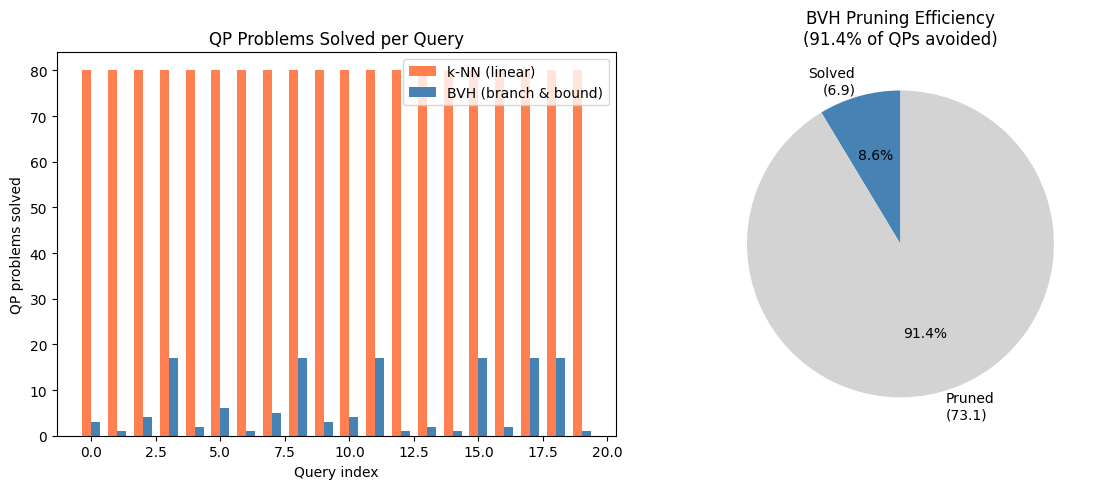

In [24]:
# Visualize QP savings
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax = axes[0]
x_pos = np.arange(n_test)
width = 0.35
ax.bar(x_pos - width/2, knn_qps, width, label='k-NN (linear)', color='coral')
ax.bar(x_pos + width/2, bvh_qps, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('QP problems solved')
ax.set_title('QP Problems Solved per Query')
ax.legend()

# Pie chart
ax = axes[1]
avg_bvh = np.mean(bvh_qps)
avg_knn = np.mean(knn_qps)
pruned = avg_knn - avg_bvh

ax.pie([avg_bvh, pruned],
       labels=[f'Solved\n({avg_bvh:.1f})', f'Pruned\n({pruned:.1f})'],
       colors=['steelblue', 'lightgray'],
       autopct='%1.1f%%',
       startangle=90)
ax.set_title(f'BVH Pruning Efficiency\n({pruned/avg_knn*100:.1f}% of QPs avoided)')

plt.tight_layout()
plt.show()

## Summary

The **CertifiedAtlas** provides a simple API for certified counterfactual generation:

```python
# Build atlas (offline)
atlas = CertifiedAtlas(model, dataset, device)
atlas.build(eps=0.1, norm=2)

# Generate counterfactual (online)
result = atlas.find_counterfactual(x_query, target_class=3)
```

Key features:
- **Certified validity**: Counterfactuals are guaranteed to be classified correctly
- **Efficient search**: BVH indexing prunes most QP computations
- **Flexible parameters**: Control perturbation radius (`eps`) and norm

In [25]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neighbors import KernelDensity
from dataclasses import dataclass
from typing import List, Dict
import pandas as pd


@dataclass
class CounterfactualMetrics:
    """Metrics for a single counterfactual."""
    # Basic info
    query_idx: int
    source_class: int
    target_class: int
    success: bool
    
    # Proximity metrics
    l1_distance: float
    l2_distance: float
    linf_distance: float
    
    # Sparsity
    n_features_changed: int
    sparsity_ratio: float  # fraction of features changed
    
    # Certified robustness
    validity_radius: float  # min margin to polytope boundary
    
    # Plausibility
    lof_score: float  # Local Outlier Factor (lower = more normal)
    kde_log_density: float  # log density at counterfactual


def compute_validity_radius(x_cf: np.ndarray, A: np.ndarray, b: np.ndarray, 
                            center: np.ndarray, eps: float, norm: int) -> float:
    """
    Compute the validity radius (δ-robustness) for a counterfactual.
    
    This is the minimum "margin" to any constraint, indicating how deep
    inside the certified polytope the counterfactual lies.
    """
    if x_cf is None:
        return 0.0
    
    # Margin to LiRPA constraints: A @ x + b >= 0
    lirpa_margins = A @ x_cf + b
    
    # Margin to ball boundary
    if norm == 2:
        ball_margin = eps - np.linalg.norm(x_cf - center)
    elif norm == 1:
        ball_margin = eps - np.sum(np.abs(x_cf - center))
    else:  # L∞
        ball_margin = eps - np.max(np.abs(x_cf - center))
    
    # The validity radius is the minimum of all margins
    return min(np.min(lirpa_margins), ball_margin)


def compute_metrics_for_counterfactual(
    x_query: np.ndarray,
    x_cf: np.ndarray,
    query_idx: int,
    source_class: int,
    target_class: int,
    result,
    atlas,
    lof_model,
    kde_model,
    change_threshold: float = 0.01
) -> CounterfactualMetrics:
    """Compute all metrics for a single counterfactual."""
    
    if not result.success or x_cf is None:
        return CounterfactualMetrics(
            query_idx=query_idx,
            source_class=source_class,
            target_class=target_class,
            success=False,
            l1_distance=np.inf,
            l2_distance=np.inf,
            linf_distance=np.inf,
            n_features_changed=0,
            sparsity_ratio=0.0,
            validity_radius=0.0,
            lof_score=np.inf,
            kde_log_density=-np.inf
        )
    
    # Proximity metrics
    diff = x_cf - x_query
    l1_dist = np.sum(np.abs(diff))
    l2_dist = np.linalg.norm(diff)
    linf_dist = np.max(np.abs(diff))
    
    # Sparsity
    n_features = len(x_query)
    features_changed = np.abs(diff) > change_threshold
    n_changed = np.sum(features_changed)
    sparsity = n_changed / n_features
    
    # Validity radius
    bd = atlas.bounds[target_class]
    idx = result.anchor_idx
    validity_radius = compute_validity_radius(
        x_cf, bd['lA'][idx], bd['lbias'][idx], 
        bd['X'][idx], atlas.eps, atlas.norm
    )
    
    # LOF score (negative_outlier_factor_ is negative, more negative = more outlier)
    lof_score = -lof_model.score_samples(x_cf.reshape(1, -1))[0]
    
    # KDE log density
    kde_log_density = kde_model.score_samples(x_cf.reshape(1, -1))[0]
    
    return CounterfactualMetrics(
        query_idx=query_idx,
        source_class=source_class,
        target_class=target_class,
        success=True,
        l1_distance=l1_dist,
        l2_distance=l2_dist,
        linf_distance=linf_dist,
        n_features_changed=n_changed,
        sparsity_ratio=sparsity,
        validity_radius=validity_radius,
        lof_score=lof_score,
        kde_log_density=kde_log_density
    )

## 9 – Counterfactual Quality Metrics

We evaluate counterfactuals using several standard metrics:

### Standard Metrics
- **Validity Rate**: Fraction of counterfactuals correctly classified as target
- **Proximity (L1, L2, L∞)**: Distance from query to counterfactual
- **Sparsity**: Fraction of features changed significantly

### Certified Robustness
- **Validity Radius (δ-robustness)**: Minimum margin to polytope boundary — measures how "deep" inside the certified region the counterfactual lies

### Plausibility  
- **Local Outlier Factor (LOF)**: Measures if counterfactual is an outlier relative to target class data
- **KDE Density**: Kernel density estimate at counterfactual location

In [26]:
# Generate counterfactuals for all samples and compute metrics
print("Generating counterfactuals for all samples...\n")

# Store all metrics
all_metrics: List[CounterfactualMetrics] = []

# For each source class, generate counterfactuals to all other classes
n_samples_per_class = 20  # Use subset for faster computation

for source_class in range(atlas.n_classes):
    # Get query points from this class
    source_data = atlas.bounds[source_class]['X'][:n_samples_per_class]
    
    for target_class in range(atlas.n_classes):
        if target_class == source_class:
            continue
        
        # Fit LOF and KDE on target class data
        target_data = atlas.bounds[target_class]['X']
        
        lof_model = LocalOutlierFactor(n_neighbors=min(20, len(target_data)-1), novelty=True)
        lof_model.fit(target_data)
        
        kde_model = KernelDensity(kernel='gaussian', bandwidth=0.1)
        kde_model.fit(target_data)
        
        # Generate counterfactuals
        n_success = 0
        for i, x_query in enumerate(source_data):
            result = atlas.find_counterfactual(x_query, target_class, method='bvh')
            
            metrics = compute_metrics_for_counterfactual(
                x_query=x_query,
                x_cf=result.x_cf if result.success else None,
                query_idx=i,
                source_class=source_class,
                target_class=target_class,
                result=result,
                atlas=atlas,
                lof_model=lof_model,
                kde_model=kde_model
            )
            all_metrics.append(metrics)
            
            if result.success:
                n_success += 1
        
        print(f"Class {source_class} → {target_class}: {n_success}/{len(source_data)} successful")

print(f"\nTotal counterfactuals generated: {len(all_metrics)}")

# Convert metrics to DataFrame for analysis
metrics_df = pd.DataFrame([vars(m) for m in all_metrics])

Generating counterfactuals for all samples...

Class 0 → 1: 20/20 successful
Class 0 → 2: 20/20 successful
Class 0 → 3: 20/20 successful
Class 0 → 4: 20/20 successful
Class 1 → 0: 20/20 successful
Class 1 → 2: 20/20 successful
Class 1 → 3: 20/20 successful
Class 1 → 4: 20/20 successful
Class 2 → 0: 20/20 successful
Class 2 → 1: 20/20 successful
Class 2 → 3: 20/20 successful
Class 2 → 4: 20/20 successful
Class 3 → 0: 20/20 successful
Class 3 → 1: 20/20 successful
Class 3 → 2: 20/20 successful
Class 3 → 4: 20/20 successful
Class 4 → 0: 20/20 successful
Class 4 → 1: 20/20 successful
Class 4 → 2: 20/20 successful
Class 4 → 3: 20/20 successful

Total counterfactuals generated: 400


In [34]:
metrics_df

,query_idx,source_class,target_class,success,l1_distance,l2_distance,linf_distance,n_features_changed,sparsity_ratio,validity_radius,lof_score,kde_log_density
0,0,0,1,True,0.913726,0.722836,0.686040,2,1.0,-3.898155e-09,1.103702,0.878000
1,1,0,1,True,0.945144,0.801078,0.784884,2,1.0,-1.880485e-09,1.103702,0.878000
2,2,0,1,True,0.804793,0.759502,0.758063,2,1.0,-1.612953e-09,1.103702,0.878000
3,3,0,1,True,0.124273,0.102339,0.099227,2,1.0,-5.889067e-12,1.060440,0.954770
4,4,0,1,True,0.890697,0.805408,0.800322,2,1.0,-5.329071e-14,1.103702,0.878000
...,...,...,...,...,...,...,...,...,...,...,...,...
395,15,4,3,True,0.349969,0.349078,0.349077,1,0.5,-8.806265e-11,1.086034,-0.301259
396,16,4,3,True,0.354629,0.262206,0.231496,2,1.0,-4.174439e-14,1.033321,0.934580
397,17,4,3,True,0.509996,0.395920,0.370550,2,1.0,-5.380976e-11,1.100943,-0.422588
398,18,4,3,True,0.652880,0.463626,0.356626,2,1.0,-5.052621e-11,1.083824,-0.153103


INFO     16:06:38     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     16:06:38     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     16:06:38     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     16:06:38     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     16:06:38     [category.py:224] Using categorical units to plot a list o

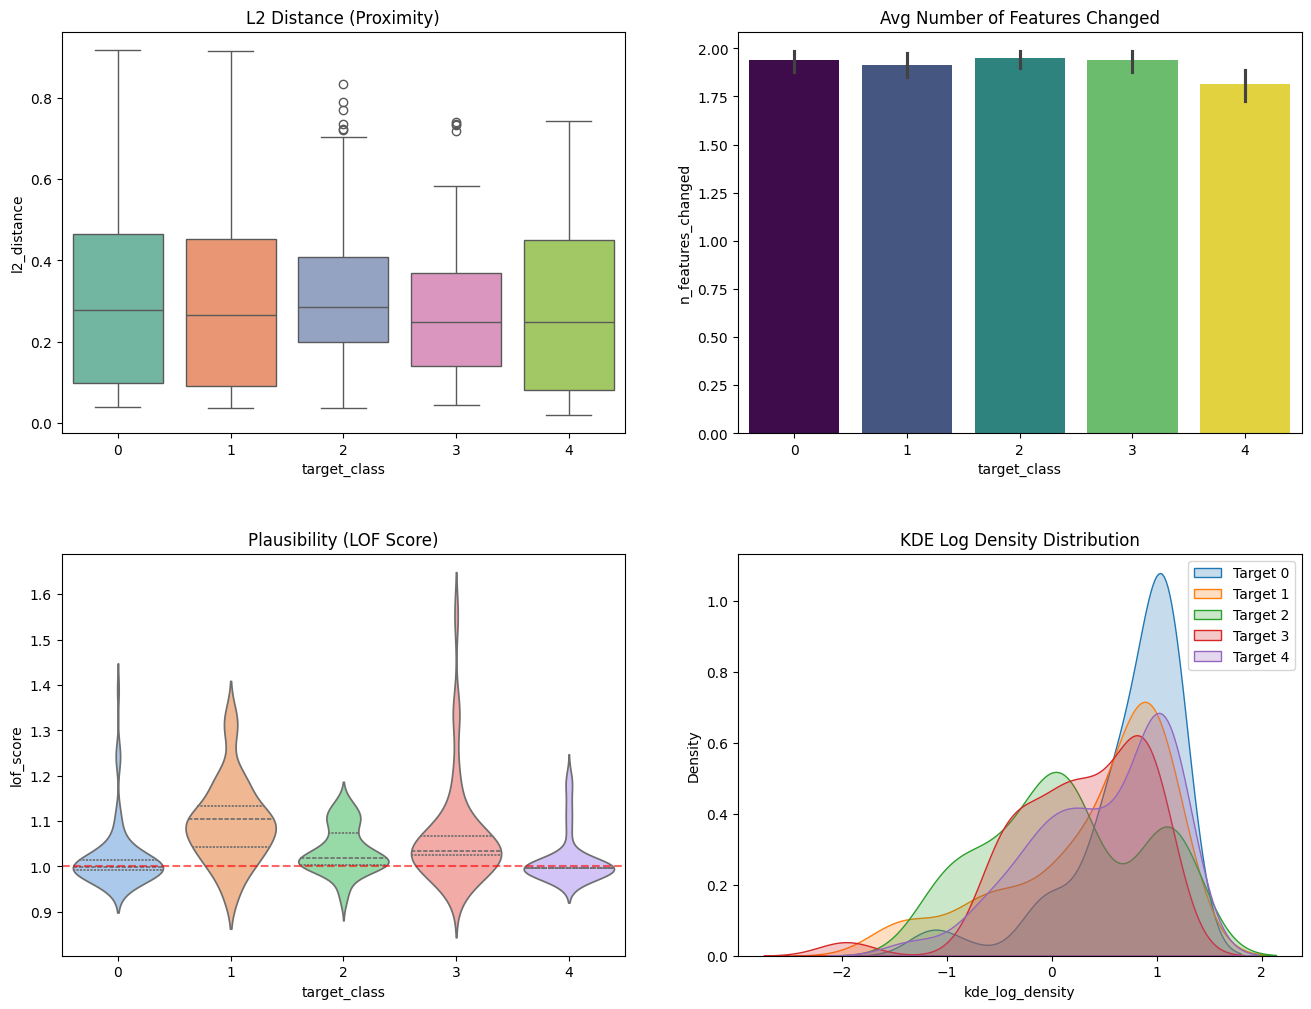

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# 1. Data Type Correction & Prep
# This solves the "categorical units" info message
metrics_df['target_class'] = metrics_df['target_class'].astype(int)
metrics_df['source_class'] = metrics_df['source_class'].astype(int)

# Silence the internal Matplotlib 'vert' warning
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# 2. Aggregate Statistics
class_comparison = metrics_df.groupby(['source_class', 'target_class']).agg({
    'l2_distance': 'mean',
    'n_features_changed': 'mean',
    'lof_score': 'mean',
    'kde_log_density': 'mean'
}).reset_index()

# 3. Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

# Distance Analysis
sns.boxplot(ax=axes[0, 0], x='target_class', y='l2_distance', data=metrics_df, 
            hue='target_class', palette='Set2', legend=False, orient='v')
axes[0, 0].set_title('L2 Distance (Proximity)')

# Feature Change Analysis
sns.barplot(ax=axes[0, 1], x='target_class', y='n_features_changed', data=metrics_df, 
            hue='target_class', palette='viridis', legend=False, orient='v')
axes[0, 1].set_title('Avg Number of Features Changed')

# Plausibility (LOF Score)
sns.violinplot(ax=axes[1, 0], x='target_class', y='lof_score', data=metrics_df, 
               hue='target_class', palette='pastel', legend=False, orient='v', inner="quart")
axes[1, 0].axhline(1.0, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_title('Plausibility (LOF Score)')

# Density (KDE Log Density)
for t_class in sorted(metrics_df['target_class'].unique()):
    subset = metrics_df[metrics_df['target_class'] == t_class]
    sns.kdeplot(subset['kde_log_density'], ax=axes[1, 1], label=f'Target {t_class}', fill=True)
axes[1, 1].set_title('KDE Log Density Distribution')
axes[1, 1].legend()

plt.show()